# Silicon, part 1: from an input file to a plane-wave basis

This notebook walks through everything pypresso can currently do with a real system:
read a Quantum ESPRESSO input, build the unit cell, generate the k-points, and construct
the plane-wave basis — then check every number against the reference output that ships
with Quantum ESPRESSO for the same input.

The system is silicon in the diamond structure, taken from
`test-suite/pw_scf/scf.in`: a two-atom fcc cell, LDA, a 12 Ry wavefunction cutoff and
two explicit k-points. It is small enough that every intermediate quantity can be
checked by hand, which is why it is the project's canonical first target.

**What this covers:** phases P0–P2 of `PLAN.md` (scaffolding, geometry, basis).
There is no self-consistent field yet — no density, no eigenvalues, no total energy.
Those arrive in later notebooks as the phases land.

## 0. Setup

Importing `pypresso` enables JAX's 64-bit mode before any array can be created. Single precision would not converge an SCF, and no comparison against Quantum ESPRESSO would be meaningful in it, so this happens at import time rather than being left to the caller.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

import pypresso
from pypresso.io import read_qe_output
from pypresso.io.pwin import read_pw_input

QE = Path("../quantum_espresso/qe-7.5-ReleasePack/qe-7.5/test-suite")
INPUT = QE / "pw_scf" / "scf.in"
BENCHMARK = QE / "pw_scf" / "benchmark.out.git.inp=scf.in"

print("pypresso", pypresso.__version__)
print("input file present:", INPUT.is_file())
print("reference output present:", BENCHMARK.is_file())

pypresso 0.0.1
input file present: True
reference output present: True


### The input we are reproducing

In [2]:
print(INPUT.read_text())

 &control
    calculation = 'scf'
    tstress=.true.
 /
 &system
    ibrav=2, celldm(1) =10.20, 
    nat=2, ntyp=1,
    ecutwfc=12.0
 /
 &electrons
 /
ATOMIC_SPECIES
 Si  28.086  Si.pz-vbc.UPF
ATOMIC_POSITIONS (alat)
 Si 0.00 0.00 0.00
 Si 0.25 0.25 0.25
K_POINTS
  2 
   0.250000  0.250000  0.250000   1.00
   0.250000  0.250000  0.750000   3.00



## 1. Parsing the input

`read_pw_input` handles Fortran namelist syntax and Quantum ESPRESSO's cards. It only
tokenises — it deliberately knows nothing about what an `ibrav` means, so that the same
parser works for the other codes' inputs later.

Note what it does *not* do: invent defaults. `ecutrho` is absent from this input, and
`get` returns `None` rather than silently supplying `4 * ecutwfc`. Defaults are
context-dependent in Quantum ESPRESSO, so they are applied one layer up where the context
is known.

In [3]:
pwin = read_pw_input(INPUT)

for name, entries in pwin.namelists.items():
    print(f"&{name}")
    for key, value in entries.items():
        print(f"    {key:<16} {value!r}")

print()
for name, card in pwin.cards.items():
    print(f"{name}  (option: {card.option})")
    for line in card.lines:
        print("   ", line)

print()
print("ecutwfc given:  ", pwin.get("system", "ecutwfc"))
print("ecutrho given:  ", pwin.get("system", "ecutrho"), "  <- absent, not guessed here")

&control
    calculation      'scf'
    tstress          True
&system
    ibrav            2
    celldm           {(1,): 10.2}
    nat              2
    ntyp             1
    ecutwfc          12.0
&electrons

ATOMIC_SPECIES  (option: None)
    Si  28.086  Si.pz-vbc.UPF
ATOMIC_POSITIONS  (option: alat)
    Si 0.00 0.00 0.00
    Si 0.25 0.25 0.25
K_POINTS  (option: None)
    2
    0.250000  0.250000  0.250000   1.00
    0.250000  0.250000  0.750000   3.00

ecutwfc given:   12.0
ecutrho given:   None   <- absent, not guessed here


## 2. The unit cell

`build_system` is the one place that knows Quantum ESPRESSO's input conventions: which
cell parameters take precedence, what a card's units mean, and which defaults apply.
Everything downstream takes the resulting `System` and never looks at an input file again.

`ibrav=2` with `celldm(1)=10.20` is the face-centred cubic lattice. The particular
lattice vectors matter: they are not merely *a* valid basis for fcc, they are Quantum
ESPRESSO's choice of basis, including its sign and ordering conventions. Every later
comparison — G-vector sets, symmetry operations, k-point coordinates — depends on
matching them exactly.

In [4]:
from pypresso.system import build_system

system = build_system(pwin)
cell = system.cell

print(cell)
print()
print("lattice vectors in units of alat (rows a1, a2, a3):")
print(np.asarray(cell.at_alat))
print()
print("reciprocal vectors in units of 2*pi/alat (rows b1, b2, b3):")
print(np.asarray(cell.bg_2pi_alat))
print()
print("alat            = %.6f bohr" % cell.alat)
print("volume          = %.4f bohr^3   (a^3/4 for the fcc primitive cell = %.4f)"
      % (cell.volume, cell.alat**3 / 4))
print("ecutwfc         = %.1f Ry" % system.ecutwfc)
print("ecutrho         = %.1f Ry   (defaulted to 4 * ecutwfc)" % system.ecutrho)

Cell(ibrav=2 [cubic F (fcc)], alat=10.200000 bohr, volume=265.3020)

lattice vectors in units of alat (rows a1, a2, a3):
[[-0.5  0.   0.5]
 [ 0.   0.5  0.5]
 [-0.5  0.5  0. ]]

reciprocal vectors in units of 2*pi/alat (rows b1, b2, b3):
[[-1. -1.  1.]
 [ 1.  1.  1.]
 [-1.  1. -1.]]

alat            = 10.200000 bohr
volume          = 265.3020 bohr^3   (a^3/4 for the fcc primitive cell = 265.3020)
ecutwfc         = 12.0 Ry
ecutrho         = 48.0 Ry   (defaulted to 4 * ecutwfc)


The reciprocal cell is derived, not stored. That is deliberate: stress is the
derivative of the total energy with respect to strain, so the volume and the reciprocal
vectors have to move when the lattice does. Since they are computed from `at` on demand,
`jax.grad` flows straight through them.

In [5]:
import jax

from pypresso.system.cell import Cell

# d(volume)/d(at) -- the quantity a stress calculation needs.
gradient = jax.grad(lambda at: Cell(at=at, alat=cell.alat).volume)(cell.at)

print("d(volume)/d(at) =")
print(np.asarray(gradient))
print()
print("analytically V * (at^-1)^T =")
print(float(cell.volume) * np.linalg.inv(np.asarray(cell.at)).T)

d(volume)/d(at) =
[[-26.01 -26.01  26.01]
 [ 26.01  26.01  26.01]
 [-26.01  26.01 -26.01]]

analytically V * (at^-1)^T =
[[-26.01 -26.01  26.01]
 [ 26.01  26.01  26.01]
 [-26.01  26.01 -26.01]]


## 3. The atoms

Two silicon atoms, written in the input in units of `alat`. Internally everything is in
Rydberg atomic units — energies in Ry, lengths in bohr — matching Quantum ESPRESSO, and
conversion happens only at the input/output boundary.

The positions are a JAX array rather than static metadata because forces are the gradient
of the total energy with respect to them.

In [6]:
structure = system.structure

print("species:", [(s.name, s.mass, s.pseudo_file) for s in structure.species])
print()
print("positions (bohr):")
print(np.asarray(structure.positions))
print()
print("positions (crystal / fractional):")
print(np.asarray(structure.positions_crystal(cell)))
print()
print("nearest-neighbour distance = %.4f bohr  (sqrt(3)/4 * a = %.4f)"
      % (np.linalg.norm(np.asarray(structure.positions[1] - structure.positions[0])),
         np.sqrt(3) / 4 * cell.alat))

species: [('Si', 28.086, 'Si.pz-vbc.UPF')]

positions (bohr):
[[0.   0.   0.  ]
 [2.55 2.55 2.55]]

positions (crystal / fractional):
[[ 0.    0.    0.  ]
 [-0.25  0.75 -0.25]]



nearest-neighbour distance = 4.4167 bohr  (sqrt(3)/4 * a = 4.4167)


## 4. k-points

This input lists its two k-points explicitly, with weights 1 and 3. Quantum ESPRESSO
normalises weights to sum to 1 and then multiplies by 2 for a spin-degenerate
calculation, so the printed weights are 0.5 and 1.5 — which is what we produce.

Coordinates follow Quantum ESPRESSO's convention: cartesian, in units of `2*pi/alat`.

In [7]:
kpoints = system.kpoints

print("k-points (cartesian, units 2*pi/alat):")
print(np.asarray(kpoints.coords))
print("weights:", np.asarray(kpoints.weights), " sum =", float(kpoints.weights.sum()))
print()
print("the same points in crystal coordinates:")
print(np.asarray(kpoints.crystal(cell)))
print()
print("and in 1/bohr, which is what |k+G|^2 needs:")
print(np.asarray(kpoints.cartesian(cell)))

k-points (cartesian, units 2*pi/alat):
[[0.25 0.25 0.25]
 [0.25 0.25 0.75]]
weights: [0.5 1.5]  sum = 2.0

the same points in crystal coordinates:
[[0.   0.25 0.  ]
 [0.25 0.5  0.  ]]

and in 1/bohr, which is what |k+G|^2 needs:
[[0.15399964 0.15399964 0.15399964]
 [0.15399964 0.15399964 0.46199892]]


## 5. The plane-wave basis

Now the part that this phase of the project was really about.

A plane-wave calculation has two G-vector sets. The **dense** set holds the charge density
and potential out to `ecutrho`; the **smooth** set holds wavefunction quantities out to
`4 * ecutwfc`. For norm-conserving pseudopotentials these coincide, which is why Quantum
ESPRESSO prints only one grid here.

The FFT grid is not a free parameter. It has to be large enough that the G-sphere touches
but does not overlap its periodic image, and it has to factorise into sizes the FFT library
likes (products of 2, 3 and 5 in practice). Both rules are Quantum ESPRESSO's, reproduced
exactly, because the grid dimensions determine `ngm` and therefore every subsequent
number.

In [8]:
from pypresso.basis.builder import build_basis

basis = build_basis(system)
gvectors = basis.dense

print("dense grid:  %d G-vectors,  FFT dimensions %s" % (gvectors.ngm, gvectors.grid))
print("smooth grid is the same object:", basis.smooth is basis.dense,
      "  (dual = %.1f, so no double grid)" % (system.ecutrho / system.ecutwfc))
print()
print("Miller indices of the first few G-vectors:")
print(np.asarray(gvectors.miller[:8]))
print()
print("|G|^2 in units of (2*pi/alat)^2:", np.asarray(gvectors.g2(cell))[:8])

dense grid:  1459 G-vectors,  FFT dimensions (15, 15, 15)
smooth grid is the same object: True   (dual = 4.0, so no double grid)

Miller indices of the first few G-vectors:
[[ 0  0  0]
 [-1 -1 -1]
 [-1  0  0]
 [ 0 -1  0]
 [ 0  0 -1]
 [ 0  0  1]
 [ 0  1  0]
 [ 1  0  0]]

|G|^2 in units of (2*pi/alat)^2: [0. 3. 3. 3. 3. 3. 3. 3.]


What is stored is the **Miller indices** — integers, fixed for the whole run — and not
the cartesian components. Cartesian G is a function of the cell, computed on demand. If the
components were stored, the cell would be silently frozen and stress-by-differentiation
would be impossible.

The G-vectors come out sorted by magnitude, with G = 0 first (many formulas treat the
G = 0 term specially), and they fall into shells of equal `|G|^2` set by the lattice
symmetry.

In [9]:
g2 = np.asarray(gvectors.g2(cell))
shells, counts = np.unique(np.round(g2, 8), return_counts=True)

print("first ten shells of the fcc reciprocal lattice:")
print(" |G|^2   multiplicity")
for value, count in zip(shells[:10], counts[:10]):
    print("%6.1f   %d" % (value, count))

first ten shells of the fcc reciprocal lattice:
 |G|^2   multiplicity
   0.0   1
   3.0   8
   4.0   6
   8.0   12
  11.0   24
  12.0   8
  16.0   6
  19.0   24
  20.0   24
  24.0   24


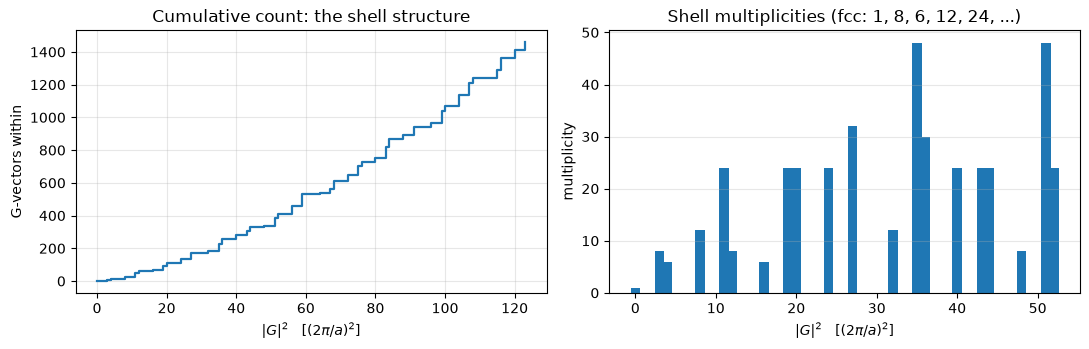

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))

axes[0].step(shells, np.cumsum(counts), where="post", lw=1.6)
axes[0].set_xlabel(r"$|G|^2$   [$(2\pi/a)^2$]")
axes[0].set_ylabel("G-vectors within")
axes[0].set_title("Cumulative count: the shell structure")
axes[0].grid(alpha=0.3)

axes[1].bar(shells[:20], counts[:20], width=1.2)
axes[1].set_xlabel(r"$|G|^2$   [$(2\pi/a)^2$]")
axes[1].set_ylabel("multiplicity")
axes[1].set_title("Shell multiplicities (fcc: 1, 8, 6, 12, 24, ...)")
axes[1].grid(alpha=0.3, axis="y")

fig.tight_layout()

### Plane waves at each k-point

The wavefunction at k is expanded in the plane waves with `|k+G|^2 <= ecutwfc`. That count
differs from k-point to k-point — exactly the ragged shape JAX cannot tolerate.

The resolution is Quantum ESPRESSO's own: allocate to `npwx = max_k npw_k` and carry a
boolean mask. Nothing downstream may branch on `npw_k`; it multiplies by the mask instead,
so every k-point traces to the same compiled program and the k-axis stays `vmap`-able and
shardable across devices later.

In [11]:
planewaves = basis.planewaves

print("plane waves per k-point:", planewaves.npw)
print("npwx (padded width)    :", planewaves.npwx)
print("mask shape             :", planewaves.mask.shape,
      " -> %d real, %d padding" % (int(planewaves.mask.sum()),
                                   int((~planewaves.mask).sum())))

kinetic = np.asarray(planewaves.kinetic(gvectors, kpoints, cell))
mask = np.asarray(planewaves.mask)
print()
print("largest |k+G|^2 retained: %.4f Ry   (cutoff %.1f Ry)"
      % (kinetic[mask].max(), system.ecutwfc))
print("padding entries contribute:", np.abs(kinetic[~mask]).max())

plane waves per k-point: (180, 186)
npwx (padded width)    : 186
mask shape             : (2, 186)  -> 366 real, 6 padding

largest |k+G|^2 retained: 11.8342 Ry   (cutoff 12.0 Ry)
padding entries contribute: 0.0


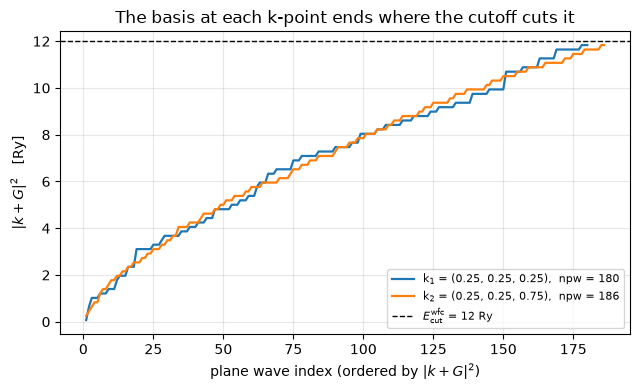

In [12]:
fig, ax = plt.subplots(figsize=(6.5, 4))

for ik in range(planewaves.nk):
    npw = planewaves.npw[ik]
    ax.plot(np.arange(1, npw + 1), kinetic[ik, :npw], lw=1.6,
            label=r"k$_%d$ = (%.2f, %.2f, %.2f),  npw = %d"
                  % (ik + 1, *np.asarray(kpoints.coords[ik]), npw))

ax.axhline(system.ecutwfc, color="k", ls="--", lw=1,
           label=r"$E_{\rm cut}^{\rm wfc}$ = %.0f Ry" % system.ecutwfc)
ax.set_xlabel("plane wave index (ordered by $|k+G|^2$)")
ax.set_ylabel(r"$|k+G|^2$   [Ry]")
ax.set_title("The basis at each k-point ends where the cutoff cuts it")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
fig.tight_layout()

## 6. Fourier transforms

The transforms move between the G-vector sphere and the real-space FFT box. Two
conventions are fixed once and used everywhere:

$$f(\mathbf r) = \sum_{\mathbf G} c_{\mathbf G}\, e^{i\mathbf G\cdot\mathbf r},
\qquad
c_{\mathbf G} = \frac{1}{N}\sum_{\mathbf r} f(\mathbf r)\, e^{-i\mathbf G\cdot\mathbf r}$$

which is Quantum ESPRESSO's scaling (`invfft` unscaled, `fwfft` divided by the number of
grid points). NumPy and JAX put the `1/N` on the other transform, so the code rescales
explicitly. Volume factors are *not* applied inside the transform — they are applied where
densities and matrix elements are formed, so no caller has to guess.

In [13]:
import jax.numpy as jnp

from pypresso.basis.fft import g_to_r, r_to_g

rng = np.random.default_rng(0)
coefficients = jnp.asarray(rng.normal(size=gvectors.ngm) + 1j * rng.normal(size=gvectors.ngm))

field = g_to_r(coefficients, gvectors.fft_index, gvectors.grid)
recovered = r_to_g(field, gvectors.fft_index)

n = np.prod(gvectors.grid)
print("field on the grid:", field.shape, field.dtype)
print("round-trip error  : %.2e" % float(jnp.abs(recovered - coefficients).max()))
print("Parseval:  sum|c|^2 = %.6f    (1/N) sum|f(r)|^2 = %.6f"
      % (float(jnp.sum(jnp.abs(coefficients) ** 2)),
         float(jnp.sum(jnp.abs(field) ** 2) / n)))

field on the grid: (15, 15, 15) complex128
round-trip error  : 1.49e-15


Parseval:  sum|c|^2 = 2896.647973    (1/N) sum|f(r)|^2 = 2896.647973


### A physical use of the basis: the structure factor

Nothing above has involved the atoms yet. The simplest quantity that ties the G-vectors to
the structure is the **structure factor**

$$S(\mathbf G) = \sum_a e^{-i\mathbf G\cdot\boldsymbol\tau_a}$$

Summing it back over the G-sphere gives a band-limited sum of delta functions at the
atomic sites — the sharpest object this basis can represent. It is worth plotting because
it makes the effect of a finite cutoff visible: the peaks have a width set by the largest
`|G|`, and they ring.

This is also exactly the object that P3 will multiply by a pseudopotential form factor to
build the local potential, so it is a preview of the next phase.

In [14]:
g_cart = np.asarray(gvectors.cartesian(cell))           # (ngm, 3) in 1/bohr
tau = np.asarray(structure.positions)                   # (nat, 3) in bohr

structure_factor = np.exp(-1j * g_cart @ tau.T).sum(axis=1)

print("S(G=0) =", structure_factor[0], " (equals the number of atoms)")
print("|S(G)| for the first few G:", np.abs(structure_factor[:8]).round(4))

S(G=0) = (2+0j)  (equals the number of atoms)
|S(G)| for the first few G: [2.     1.4142 1.4142 1.4142 1.4142 1.4142 1.4142 1.4142]


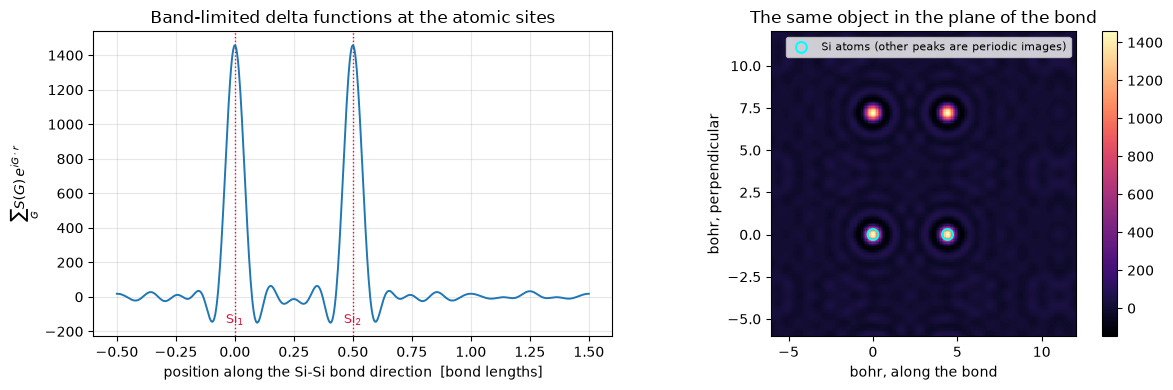

In [15]:
def evaluate(points):
    # Sum_G S(G) exp(i G.r) evaluated directly, without an FFT, so the points
    # need not lie on the grid.
    phases = np.exp(1j * points @ g_cart.T)             # (npoints, ngm)
    return (phases * structure_factor).sum(axis=1).real


# A line through both atoms, continued to the next periodic image.
direction = tau[1] - tau[0]
t = np.linspace(-0.5, 1.5, 601)
line = tau[0] + t[:, None] * direction * 2.0

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(t, evaluate(line), lw=1.4)
bottom = axes[0].get_ylim()[0]
for position, label in ((0.0, r"Si$_1$"), (0.5, r"Si$_2$")):
    axes[0].axvline(position, color="crimson", ls=":", lw=1)
    axes[0].annotate(label, (position, bottom * 0.75), color="crimson",
                     ha="center", va="bottom", fontsize=9)
axes[0].set_xlabel("position along the Si-Si bond direction  [bond lengths]")
axes[0].set_ylabel(r"$\sum_G S(G)\, e^{iG\cdot r}$")
axes[0].set_title("Band-limited delta functions at the atomic sites")
axes[0].grid(alpha=0.3)

# A 2D map in the plane containing both atoms.
e1 = direction / np.linalg.norm(direction)
e2 = np.cross(e1, [0.0, 0.0, 1.0])
e2 /= np.linalg.norm(e2)
span = np.linspace(-6.0, 12.0, 220)
u, v = np.meshgrid(span, span, indexing="ij")
plane = tau[0] + u[..., None] * e1 + v[..., None] * e2

image = evaluate(plane.reshape(-1, 3)).reshape(u.shape)
mesh = axes[1].pcolormesh(span, span, image.T, cmap="magma", shading="auto")
axes[1].scatter([0.0, np.linalg.norm(direction)], [0.0, 0.0], s=60,
                facecolors="none", edgecolors="cyan", lw=1.5,
                label="Si atoms (other peaks are periodic images)")
axes[1].set_aspect("equal")
axes[1].set_xlabel("bohr, along the bond")
axes[1].set_ylabel("bohr, perpendicular")
axes[1].set_title("The same object in the plane of the bond")
axes[1].legend(fontsize=8, loc="upper right")
fig.colorbar(mesh, ax=axes[1])

fig.tight_layout()

The ringing around each peak is not a bug — it is the finite basis. A 12 Ry cutoff
can only resolve features down to about $\pi/|G|_{\max}$, and a delta function is far
sharper than that. This is the same truncation that decides how well the basis can
represent a real wavefunction, which is why cutoff convergence is the first thing anyone
checks in a plane-wave calculation.

## 7. Checking against Quantum ESPRESSO

Everything above is only worth something if it agrees with the reference. The project's
testing method is to run the *same input* through Quantum ESPRESSO and through pypresso
and compare numbers; here the reference is the output committed alongside the input in
Quantum ESPRESSO's own test suite.

The quantities compared in this notebook are **integers and exactly printed reals** — the
number of G-vectors, the FFT dimensions, the plane-wave count at each k-point. There is no
tolerance to hide behind.

In [16]:
reference = read_qe_output(BENCHMARK)

rows = [
    ("lattice parameter (bohr)", "%.6f" % cell.alat, "%.6f" % reference.alat),
    ("cell volume (bohr^3)", "%.4f" % cell.volume, "%.4f" % reference.volume),
    ("G-vectors (dense)", gvectors.ngm, reference.ngm_dense),
    ("FFT dimensions", str(tuple(gvectors.grid)), str(tuple(reference.fft_dense))),
    ("plane waves per k-point", str(tuple(planewaves.npw)),
     str(tuple(int(n) for n in reference.npw))),
    ("k-points", kpoints.nk, len(reference.kpoints)),
    ("sum of k-point weights", "%.4f" % float(kpoints.weights.sum()),
     "%.4f" % float(reference.weights.sum())),
]

print("%-28s %-18s %-18s %s" % ("quantity", "pypresso", "Quantum ESPRESSO", ""))
print("-" * 74)
for name, ours, theirs in rows:
    agree = "OK" if str(ours) == str(theirs) else "MISMATCH"
    print("%-28s %-18s %-18s %s" % (name, ours, theirs, agree))

print()
print("crystal axes match:    ", np.allclose(np.asarray(cell.at_alat), reference.at, atol=1e-6))
print("reciprocal axes match: ", np.allclose(np.asarray(cell.bg_2pi_alat), reference.bg, atol=1e-6))
print("k-points match:        ", np.allclose(np.asarray(kpoints.coords), reference.kpoints, atol=1e-6))

quantity                     pypresso           Quantum ESPRESSO   
--------------------------------------------------------------------------
lattice parameter (bohr)     10.200000          10.200000          OK
cell volume (bohr^3)         265.3020           265.3020           OK
G-vectors (dense)            1459               1459               OK
FFT dimensions               (15, 15, 15)       (15, 15, 15)       OK
plane waves per k-point      (180, 186)         (180, 186)         OK
k-points                     2                  2                  OK
sum of k-point weights       2.0000             2.0000             OK

crystal axes match:     True
reciprocal axes match:  True
k-points match:         True


## 8. What the reference contains that we cannot yet reproduce

The same benchmark file also holds the results of the self-consistent calculation. They are
listed here as the target for the phases that follow.

In [17]:
print("total energy      : %.8f Ry   (in %d SCF iterations)"
      % (reference.total_energy, reference.n_iterations))
for name, value in reference.energy_terms.items():
    print("    %-14s %16.8f Ry" % (name, value))
print()
print("eigenvalues (eV), shape %s:" % (reference.eigenvalues.shape,))
for ik, row in enumerate(reference.eigenvalues[0]):
    print("    k%d: %s" % (ik + 1, np.array2string(row, precision=4)))
print()
print("highest occupied level: %.4f eV" % reference.homo)
print("pressure              : %.2f kbar" % reference.pressure)

total energy      : -15.79449593 Ry   (in 5 SCF iterations)
    one-electron         4.83378641 Ry
    hartree              1.08429090 Ry
    xc                  -4.81281466 Ry
    ewald              -16.89975858 Ry

eigenvalues (eV), shape (1, 2, 4):
    k1: [-4.8701  2.3792  5.5371  5.5371]
    k2: [-2.9165 -0.0653  2.6795  4.0355]

highest occupied level: 5.5371 eV
pressure              : -30.30 kbar


## Where this goes next

| Phase | What it adds | The number it has to match |
|---|---|---|
| **P3** | UPF pseudopotentials, `vloc(G)`, projectors `vkb(k)` | form factors and the atomic charge |
| **P4** | The Hamiltonian and Davidson diagonalization | eigenvalues on a frozen potential |
| **P5** | The full SCF loop | the total energy above, term by term, to 1e-6 Ry |
| **P7** | Band structure | eigenvalues along a k-path |
| **P8** | Density of states | `dos.x` output on the same grid |

Each of those gets its own notebook in this directory as it lands.